In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:

!kaggle datasets download -d kunalgupta2616/dog-vs-cat-images-data

Dataset URL: https://www.kaggle.com/datasets/kunalgupta2616/dog-vs-cat-images-data
License(s): GPL-2.0
100% 991M/991M [00:53<00:00, 19.5MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dog-vs-cat-images-data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [37]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

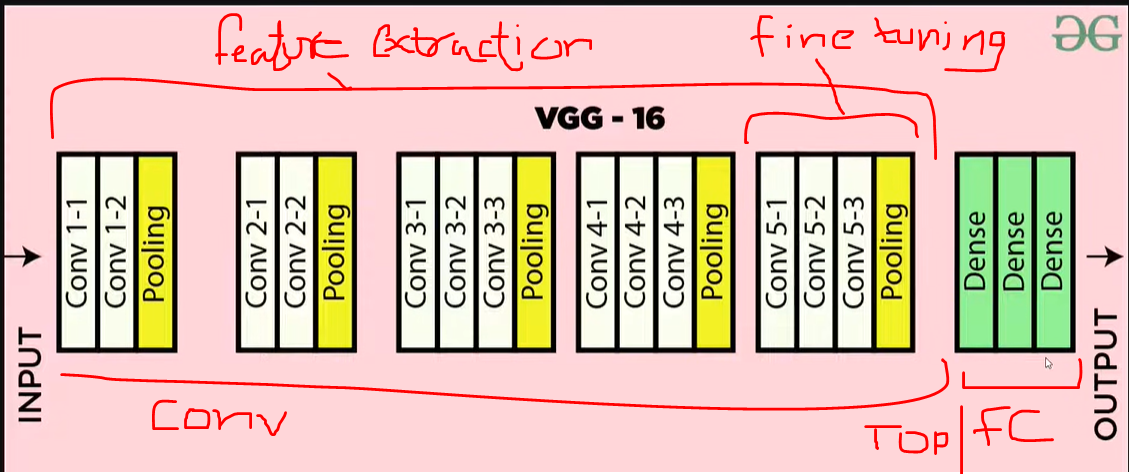

In [38]:
# for Feature extraction(import convolution layer no need top/fc layer)
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(200,200,3)
)

In [39]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 19,433,793 (74.13 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
conv_base.trainable = False

In [48]:
#Upload the data using geenrators
train_data=keras.utils.image_dataset_from_directory(
    directory = '/content/dogcat/train' ,
    labels='inferred' ,
    label_mode ='int' ,
    image_size=(200,200)
)

val_data=keras.utils.image_dataset_from_directory(
    directory='/content/dogcat/validation' ,
    labels='inferred' ,
    label_mode='int' ,
    image_size=(200,200)
)

Found 25000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.


In [20]:
for images, labels in train_data.take(1):
  print(images,labels)

tf.Tensor(
[[[[ 88.         75.         41.       ]
   [ 88.9925     76.985      39.015    ]
   [ 89.9875     77.9875     30.1125   ]
   ...
   [  0.          6.012497    1.012497 ]
   [  0.          7.0150146   2.0150146]
   [  0.          9.          4.       ]]

  [[ 88.         75.         41.       ]
   [ 88.9925     76.985      39.015    ]
   [ 89.9875     77.9875     30.1125   ]
   ...
   [  0.          6.012497    1.012497 ]
   [  0.          7.0150146   2.0150146]
   [  0.          9.          4.       ]]

  [[ 88.         75.         41.       ]
   [ 88.9925     76.985      39.015    ]
   [ 89.9875     77.9875     30.1125   ]
   ...
   [  0.          6.012497    1.012497 ]
   [  0.          7.0150146   2.0150146]
   [  0.          9.          4.       ]]

  ...

  [[169.        155.        142.       ]
   [115.405     101.405      88.405    ]
   [131.7875    117.7875    104.7875   ]
   ...
   [ 31.83754    33.83754    46.83754  ]
   [ 19.022522   21.022522   34.015015 ]
   [ 

In [45]:
# Normalize
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_data = train_data.map(process)
val_data = val_data.map(process)

In [24]:
#now values of images are between 0 - 1
for images, labels in train_data.take(1):
  print(images,labels)

tf.Tensor(
[[[[2.25197989e-03 2.55955383e-03 2.92864279e-03]
   [2.28073797e-03 2.58831214e-03 2.95740087e-03]
   [2.30949651e-03 2.61707045e-03 2.98615918e-03]
   ...
   [2.50941934e-03 2.81699328e-03 3.23221833e-03]
   [2.48066126e-03 2.78823520e-03 3.20346002e-03]
   [2.47597089e-03 2.78354483e-03 3.19876964e-03]]

  [[2.25197989e-03 2.55955383e-03 2.92864279e-03]
   [2.28073797e-03 2.58831214e-03 2.95740087e-03]
   [2.30949651e-03 2.61707045e-03 2.98615918e-03]
   ...
   [2.50941934e-03 2.81699328e-03 3.23221833e-03]
   [2.48066126e-03 2.78823520e-03 3.20346002e-03]
   [2.47597089e-03 2.78354483e-03 3.19876964e-03]]

  [[2.25197989e-03 2.55955383e-03 2.92864279e-03]
   [2.28015194e-03 2.58772587e-03 2.95681460e-03]
   [2.30949651e-03 2.61707045e-03 2.98615918e-03]
   ...
   [2.50941934e-03 2.81699328e-03 3.23221833e-03]
   [2.48066126e-03 2.78823520e-03 3.20346002e-03]
   [2.47597089e-03 2.78354483e-03 3.19876964e-03]]

  ...

  [[2.46059237e-04 3.99846205e-04 4.30603628e-04]
   [2

In [49]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_data,epochs=10,validation_data=val_data)

Epoch 1/10
475/782 ━━━━━━━━━━━━━━━━━━━━ 46s 152ms/step - accuracy: 0.9260 - loss: 2.3560

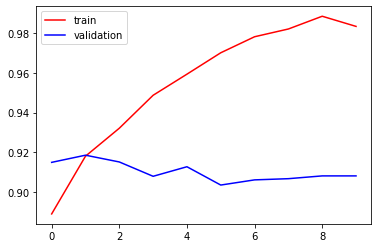

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

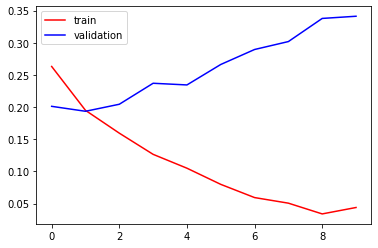

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()